**READ.ME**

This file helps you explore the functions of Brightway 2.5 in an intuitive way. So far, we have linked a background database with a simple foreground model in the previous sections of this repository.

It is not a tutorial to go through, but a collection of usable code which you can adapt for your own projects. The goal is to make Brightway 2.5 easy to use for your own projects. Any contribution to this overview is welcome.


## 🌍 Brightway 2.5 - Quick Exploration Guide

Before analyzing a Brightway model, ensure all required packages, databases, and projects are installed. These have already been set up in other scripts in this repository, so we can call them directly from the project folder stored in Brightway without re-importing or re-matching background databases.

### ⚙️ Step 1: Load Your Project

After ensuring all necessary packages are installed, you call the same project where you have installed and imported your databases. This happens through `bd.projects.set_current('LCA_Toolbox')`

In [ ]:
# basic packages from brightway
import bw2analyzer as ba
import bw2calc as bc
import bw2data as bd
import bw2io as bi
from bw2io.importers import SingleOutputEcospold2Importer
import bw2analyzer as bwa
from bw2data import methods

# other relevant packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

In [ ]:
# call the project we want to work in, in this case brightway25 where we have set up the databases
bd.projects.set_current('LCA_Toolbox')

### ⚙️ Step 2: Database overview

This section provides an overview of the background and foreground databases stored in the Brightway project.

In [ ]:
bd.databases

In [ ]:
bd.projects.current

In [ ]:
ei_bio = bd.Database('ecoinvent-3.12-biosphere')
el_bio3 = bd.Database('biosphere3')
ei_clca = bd.Database('ecoinvent-3.12-consequential')
bafu = bd.Database('bafu')
bonsai = bd.Database('BONSAI_V2.1.6')
template_consequential = bd.Database('template_consequential')

### 🔍 Step 3: Searching the Database

Use the following `database.search('')` function to search for entries in your database

In [ ]:
# search for activities in the database
template_consequential.search('ceramics')

In [ ]:
ei_clca.search('sanitary ceramics production')

#### 🧾 Step 4: Select a Process & Check Inventory

`define_name = database.get(name='', location='', unit='')` assigns the object "define_name" to the entry in the database that matches the search criteria.
    
You can directly export the inventory of the defined process to an Excel overview through `bi.export.excel.write_lci_excel(database.name, objs=[define_name], dirpath=Path.cwd())`.

    

In [ ]:
# define a process and store in a object in the project
porcelain_ceramics = template_consequential.get(name = 'production of porcelain ceramics', location = "RER", unit = 'kilogram')
sanitary_ceramics = ei_clca.get(name = 'sanitary ceramics production', location = "CH", unit = 'kilogram')

In [ ]:
# export the LCI to Microsoft Excel in an overview format
bi.export.excel.write_lci_excel(ei_clca.name, objs=[ceramics_ei], dirpath=Path.cwd())

In [ ]:
# print the outputs of the process
list(sanitary_ceramics.production())

In [ ]:
# print the consumers of a product
list(sanitary_ceramics.consumers())


In [ ]:
# (1) this is a way to print all exchanges of a process, there are multiple ways to extract this information
list(sanitary_ceramics.edges())


In [ ]:
# (2) this is an other way to print all exchanges of a process
exchanges = sorted(sanitary_ceramics.exchanges(), key=lambda exc: exc['amount'], reverse=True)
for exc in exchanges:
    print(exc)

In [ ]:
# (3) Alternative way to display all exchanges with the technosphere
list(sanitary_ceramics.technosphere())

In [ ]:
# how to check the activity type of a process
check_activity_type = print(sanitary_ceramics["activity type"])

### 🌿 Step 4: Impact Assessment Methods

To calculate the Life Cycle Impacts the back- and foreground need to be linked to an assessment method. There is a large number of available methods that are pre-installed together with the ecoinvent biosphere flows in the 01_bw25_ecoinvent_importer script.

In [20]:
# here we will analyse the set of methods that are available as part of the background
list(bd.methods)[:5]

[('CML v4.8 2016 no LT',
  'acidification no LT',
  'acidification (incl. fate, average Europe total, A&B) no LT'),
 ('CML v4.8 2016 no LT',
  'climate change no LT',
  'global warming potential (GWP100) no LT'),
 ('CML v4.8 2016 no LT',
  'ecotoxicity: freshwater no LT',
  'freshwater aquatic ecotoxicity (FAETP inf) no LT'),
 ('CML v4.8 2016 no LT',
  'ecotoxicity: marine no LT',
  'marine aquatic ecotoxicity (MAETP inf) no LT'),
 ('CML v4.8 2016 no LT',
  'ecotoxicity: terrestrial no LT',
  'terrestrial ecotoxicity (TETP inf) no LT')]

In [ ]:
# printing all methods that contain a specific keyword, e.g. "climate change"
climate_methods = [m for m in bd.methods if any("global warming potential" in str(part).lower() for part in m)]
for method in climate_methods:
    print(method)

('CML v4.8 2016 no LT', 'climate change no LT', 'global warming potential (GWP100) no LT')
('CML v4.8 2016', 'climate change', 'global warming potential (GWP100)')
('Ecological Scarcity 2021 no LT', 'climate change no LT', 'global warming potential (GWP100) no LT')
('Ecological Scarcity 2021', 'climate change', 'global warming potential (GWP100)')
('EF v3.0 no LT', 'climate change no LT', 'global warming potential (GWP100) no LT')
('EF v3.0 no LT', 'climate change: biogenic no LT', 'global warming potential (GWP100) no LT')
('EF v3.0 no LT', 'climate change: fossil no LT', 'global warming potential (GWP100) no LT')
('EF v3.0 no LT', 'climate change: land use and land use change no LT', 'global warming potential (GWP100) no LT')
('EF v3.0', 'climate change', 'global warming potential (GWP100)')
('EF v3.0', 'climate change: biogenic', 'global warming potential (GWP100)')
('EF v3.0', 'climate change: fossil', 'global warming potential (GWP100)')
('EF v3.0', 'climate change: land use and l

In [ ]:
# selecting the impact assessment methods that we want to use in our analysis
lcia_gwp100 = ('ecoinvent-3.12', 'EF v3.1', 'climate change', 'global warming potential (GWP100)')

### 📈 5. LCIA

This section shows how LCA results can be calculated quickly and be displayed as final score, process- and elementary flow based.

In [23]:
# Quick LCIA calculation
porcelain_ceramics_lca = porcelain_ceramics.lca(lcia_gwp100)
porcelain_ceramics_lca.score

0.6749479643178847

In [24]:
sanitary_ceramics_lca = sanitary_ceramics.lca(lcia_gwp100)
sanitary_ceramics_lca.score

3.088730755104976

In [27]:
# Elementary flows contribution analysis as summary table
porcelain_ceramics_lca.to_dataframe().pivot_table(index='row_name',values='amount',aggfunc='sum')

,amount
row_name,
"Carbon dioxide, fossil",0.524631
Dinitrogen monoxide,0.001083
"Methane, fossil",0.099280


In [30]:
characterized_inventory = porcelain_ceramics_lca.to_dataframe()

In [32]:
characterized_inventory.sample().T

,185
row_index,2537
col_index,5085
amount,0.000386
row_id,310402011894198291
col_id,310404084580823040
row_database,ecoinvent-3.12-biosphere
row_code,f9749677-9c9f-4678-ab55-c607dfdc2cb9
row_name,"Carbon dioxide, fossil"
row_location,None
row_unit,kilogram


In [33]:
characterized_inventory.pivot_table(index='col_location',
                                    values='amount',
                                    aggfunc='sum').sort_values(by='amount',
                                                              ascending=False)

,amount
col_location,
GLO,0.144774
RoW,0.131175
UA,0.075160
RU,0.041854
RER,0.025110
...,...
PT,0.000386
BG,0.000379
IN-AP,0.000377


### 📊 6. Contribution analysis

There are different ways to analyse the contribution analysis in Brightway 2.5. Two ways are displayed below. The max_level and cutoff can be adjusted based on the level of detail you want from the analysis.

In [34]:
# One option to do a contribution analysis is to use the recursive calculation method
bwa.print_recursive_calculation(porcelain_ceramics,
lcia_method=lcia_gwp100,max_level=1,cutoff=0.005)

Fraction of score | Absolute score | Amount | Activity
0001 | 0.6749 |     1 | 'production of porcelain ceramics' (kilogram, RER, None)
  0.213 | 0.1439 | 0.5775 | 'market for kaolin' (kilogram, GLO, None)
  0.0219 | 0.01481 | 0.275 | 'market for feldspar' (kilogram, GLO, None)
  0.017 | 0.01148 | 0.2475 | 'market for silica sand' (kilogram, GLO, None)
  0.352 | 0.2375 | 1.028 | 'market group for electricity, high voltage' (kilowatt hour, RER, None)
  0.35 | 0.2363 | 0.4507 | 'market group for natural gas, high pressure' (cubic meter, Europe without Switzerland, None)
  0.0459 | 0.03096 | 1.25e-10 | 'packaging glass factory construction' (unit, RER, None)


In [37]:
# One option to do a contribution analysis is to use the recursive calculation method
bwa.print_recursive_calculation(sanitary_ceramics,
lcia_method=lcia_gwp100,max_level=1,cutoff=0.005)

Fraction of score | Absolute score | Amount | Activity
0001 | 3.089 |     1 | 'sanitary ceramics production' (kilogram, CH, None)
  0.0308 | 0.09502 | 4e-09 | 'ceramic factory construction' (unit, CH, None)
  0.0582 | 0.1798 | 0.878 | 'market for electricity, medium voltage' (kilowatt hour, CH, None)
  0.00661 | 0.02041 | 0.379 | 'market for feldspar' (kilogram, GLO, None)
  0.851 | 2.629 | 22.89 | 'market for heat, district or industrial, natural gas' (megajoule, CH, None)
  0.0358 | 0.1106 | 0.444 | 'market for kaolin' (kilogram, GLO, None)
  0.00572 | 0.01766 | 0.125 | 'market for stucco' (kilogram, GLO, None)


In [35]:
# Another option is to use the recursive calculation to an object, which returns a DataFrame
porcelain_ceramics_ca = bwa.utils.recursive_calculation_to_object(porcelain_ceramics,
                                          lcia_method=lcia_gwp100,
                                          max_level=1,
                                          cutoff=0.005,
                                          as_dataframe=True,
                                          )
porcelain_ceramics_ca

,label,parent,score,fraction,amount,name,key
0,root,NaN,0.674948,1.000000,1.000000e+00,production of porcelain ceramics,"(template_consequential, 18cf9c1477062c6c32dd5..."
1,root_a,root,0.143875,0.213165,5.775000e-01,market for kaolin,"(ecoinvent-3.12-consequential, 1439cf096908796..."
2,root_b,root,0.014809,0.021941,2.750000e-01,market for feldspar,"(ecoinvent-3.12-consequential, 38b779a9752caf3..."
3,root_c,root,0.011482,0.017011,2.475000e-01,market for silica sand,"(ecoinvent-3.12-consequential, 42fbf9819e03152..."
4,root_d,root,0.237512,0.351897,1.027700e+00,"market group for electricity, high voltage","(ecoinvent-3.12-consequential, d2b2433d24c54e8..."
5,root_e,root,0.236306,0.350110,4.506667e-01,"market group for natural gas, high pressure","(ecoinvent-3.12-consequential, b575f5bf391b074..."
6,root_f,root,0.030963,0.045874,1.250000e-10,packaging glass factory construction,"(ecoinvent-3.12-consequential, 85bab1c73cbd732..."


In [36]:
# Another option is to use the recursive calculation to an object, which returns a DataFrame
sanitary_ceramics_ca = bwa.utils.recursive_calculation_to_object(sanitary_ceramics,
                                          lcia_method=lcia_gwp100,
                                          max_level=1,
                                          cutoff=0.005,
                                          as_dataframe=True,
                                          )
sanitary_ceramics_ca

,label,parent,score,fraction,amount,name,key
0,root,NaN,3.088731,1.000000,1.000000e+00,sanitary ceramics production,"(ecoinvent-3.12-consequential, 865d5e249bfa376..."
1,root_b,root,0.095020,0.030763,4.000000e-09,ceramic factory construction,"(ecoinvent-3.12-consequential, 69852bbafe615ba..."
2,root_e,root,0.179841,0.058225,8.780000e-01,"market for electricity, medium voltage","(ecoinvent-3.12-consequential, 045521b5763d77d..."
3,root_f,root,0.020410,0.006608,3.790000e-01,market for feldspar,"(ecoinvent-3.12-consequential, 38b779a9752caf3..."
4,root_h,root,2.629249,0.851239,2.289500e+01,"market for heat, district or industrial, natur...","(ecoinvent-3.12-consequential, 2fd188948680f30..."
5,root_j,root,0.110616,0.035813,4.440000e-01,market for kaolin,"(ecoinvent-3.12-consequential, 1439cf096908796..."
6,root_o,root,0.017659,0.005717,1.250000e-01,market for stucco,"(ecoinvent-3.12-consequential, 631a17914a1f2ba..."


### 🎨 7. Plot Contribution analysis graphs

In [38]:
# Filter out the parent processes that are not relevant for the contribution analysis
porcelain_ceramics_ca = porcelain_ceramics_ca.dropna(subset='parent')
sanitary_ceramics_ca = sanitary_ceramics_ca.dropna(subset='parent')

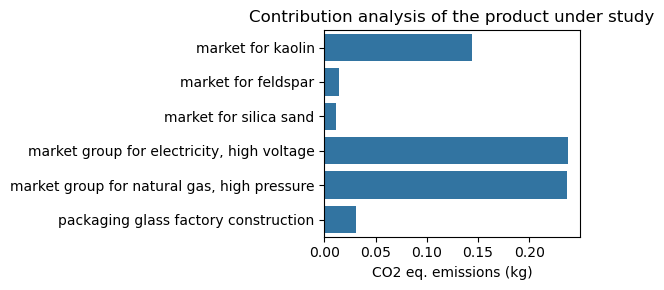

In [39]:
# First, we plot the contribution analysis for the brigthway ceramics production process
f, ax = plt.subplots(figsize=(6, 3))
sns.barplot(y='name', x='score', data=porcelain_ceramics_ca, ax=ax)
ax.set(
    title='Contribution analysis of the product under study',
    xlabel='CO2 eq. emissions (kg)',
    ylabel='')
plt.tight_layout()
plt.show()


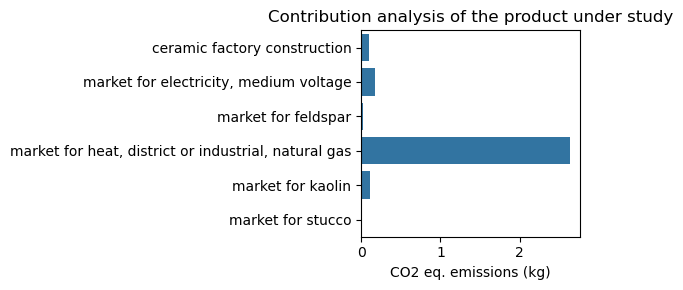

In [40]:
# First, we plot the contribution analysis for the brigthway ceramics production process
f, ax = plt.subplots(figsize=(6, 3))
sns.barplot(y='name', x='score', data=sanitary_ceramics_ca, ax=ax)
ax.set(
    title='Contribution analysis of the product under study',
    xlabel='CO2 eq. emissions (kg)',
    ylabel='')
plt.tight_layout()
plt.show()


### ⚖️ 8. Comparison

Only your creativity limits you in what you can do with the results from the impact assessment and contribution analysis. The data can also be stored in a combined dataframe (=combined_df) to then be shown in the same graph conveniently.

In [41]:
# This is an example for combining two results in one table
combined_df = pd.concat([porcelain_ceramics_ca.set_index('name').score,sanitary_ceramics_ca.set_index('name').score],
                        keys=['Porcelain ceramics','Sanitary ceramics'],
                        names=['activity','contributor'])
combined_df

activity            contributor                                         
Porcelain ceramics  market for kaolin                                       0.143875
                    market for feldspar                                     0.014809
                    market for silica sand                                  0.011482
                    market group for electricity, high voltage              0.237512
                    market group for natural gas, high pressure             0.236306
                    packaging glass factory construction                    0.030963
Sanitary ceramics   ceramic factory construction                            0.095020
                    market for electricity, medium voltage                  0.179841
                    market for feldspar                                     0.020410
                    market for heat, district or industrial, natural gas    2.629249
                    market for kaolin                                       0

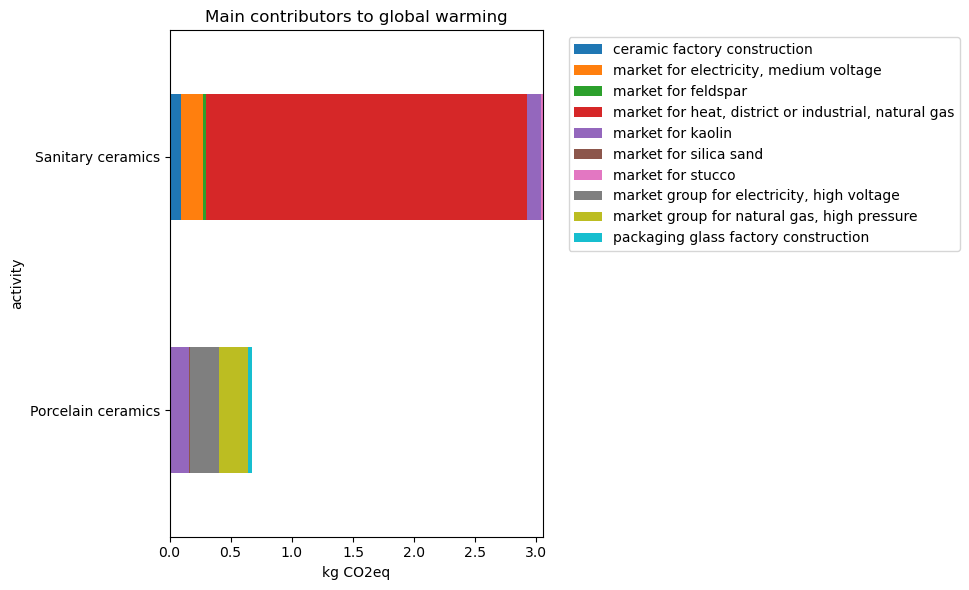

In [42]:
ax = combined_df.unstack().plot.barh(
    stacked=True,
    title='Main contributors to global warming',
    xlabel='kg CO2eq',
    figsize=(10,6)
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # moves legend outside
plt.tight_layout()
plt.show()

### 🖥️ 9. Use brightway interfaces to change inventory data

This is used in EU HyperCOG and EU REED in 2-0 LCA projects to demonstrate the integration of live machining data into LCAs.